### The following libraries are required to run the code.
1. RetinaFace: `pip install retinaface` [pypi](https://pypi.org/project/retina-face/)
2. DeepFace: `pip install deepface`  [pypi](https://pypi.org/project/deepface/)
3. Tensorflow: `pip install tf-keras`

In [15]:
""" Uncomment the following lines and hit `Ctr+Enter` to install them. """

!pip install retinaface
!pip install deepface
!pip install tf-keras

Defaulting to user installation because normal site-packages is not writeable
  Using cached retinaface-1.1.1-py3-none-any.whl.metadata (2.1 kB)
INFO: pip is looking at multiple versions of retinaface to determine which version is compatible with other requirements. This could take a while.
  Using cached retinaface-1.1.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached retinaface-0.0.6-py3-none-any.whl.metadata (1.6 kB)
  Using cached retinaface-0.0.5-py3-none-any.whl.metadata (1.4 kB)
  Using cached retinaface-0.0.4-py3-none-any.whl.metadata (725 bytes)
  Using cached retinaface-0.0.3-py3-none-any.whl.metadata (725 bytes)
  Using cached retinaface-0.0.2-py3-none-any.whl.metadata (725 bytes)
  Using cached retinaface-0.0.1-py3-none-any.whl.metadata (725 bytes)
INFO: pip is still looking at multiple versions of retinaface to determine which version is compatible with other requirements. This could take a while.

The conflict is caused by:
    retinaface 1.1.1 depends on tensorflow==2.

ERROR: Cannot install retinaface==0.0.1, retinaface==0.0.2, retinaface==0.0.3, retinaface==0.0.4, retinaface==0.0.5, retinaface==0.0.6, retinaface==1.1.0 and retinaface==1.1.1 because these package versions have conflicting dependencies.
ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Face detection and recognition models
from deepface import DeepFace # It's  a deepface full package that contains both detection and recognition of faces with more alternative models (tasks)
from retinaface import RetinaFace # This is the model for face detection which is adopted in this code.

## Face Detection using `RetinaFace` Model
1. Read the input image for detection

2. Detect Faces and Facial landmarks
3. Visualize detected faces along with facial landmarks

In [ ]:
##
dataset_meta = '/content/drive/MyDrive/COSC330/Dataset.csv'
import pandas as pd

df = pd.read_csv(dataset_meta)
df.head()

In [ ]:
##
df.value_counts("label")
for artist, dfa in df.groupby("label"):
  break
dfa.sample(frac=0.8).head()

In [ ]:
##
dfa.sample(frac=.8).shape

In [ ]:
##
# prompt: give a function that creates a train-test set from the dataframe df, downsampling each label to a specified percentage for the train set and taking the rest as test set

def create_train_test_set(df, downsample_percentage=0.8):
  """
  Creates train and test sets from a dataframe, downsampling each label for the train set.

  Args:
      df: The input DataFrame with a 'label' column.
      downsample_percentage: The percentage of each label to include in the train set (default is 0.8).

  Returns:
      A tuple containing the train and test DataFrames.
  """
  train_df = pd.DataFrame()
  test_df = pd.DataFrame()

  for label, group in df.groupby('label'):
      # Sample the group for the train set
      train_group = group.sample(frac=downsample_percentage, random_state=42)  # Use a random state for reproducibility

      # Add the train samples to the train set
      train_df = pd.concat([train_df, train_group], ignore_index=True)

      # Add the rest to the test set
      test_df = pd.concat([test_df, group.drop(train_group.index)], ignore_index=True)

  return train_df, test_df


In [ ]:
train_df, test_df = create_train_test_set(df)

In [ ]:
print(train_df.shape, test_df.shape)

In [ ]:
test_df[test_df.label=="Brad Pitt"].shape

In [ ]:

img_path = "/content/drive/MyDrive/Colab Notebooks/lab_image2.png" # put you own path

# """Read the image """
img = cv2.imread(img_path)
print(f'Input image shape: {img.shape}') # (H, W, Channel)

In [ ]:
""" Run Face detection """
detected_faces = RetinaFace.detect_faces(
    img_path=img_path,
    threshold=0.9,
)

print(f"Detected faces: {detected_faces}")
print(f"Total Faces: {len(detected_faces.keys())}")
print(f"Faces: {detected_faces.keys()}")
##

In [ ]:
def visualize(detected_faces):
    """ Define colors for facial landmarks """
    landmark_color = [
        (255,   0,   0), # right eye
        (  0,   0, 255), # left eye
        (  0, 255,   0), # nose tip
        (255,   0, 255), # right mouth corner
        (  0, 255, 255)  # left mouth corner
    ]

    for key in detected_faces.keys():
        identity = detected_faces[key] # identity: {'score': 0.9992936849594116, 'facial_area': [710, 240, 735, 270], 'landmarks': {'right_eye': [721.69055, 253.59639], 'left_eye': [732.4018, 252.42545], 'nose': [729.3393, 259.64685], 'mouth_right': [722.98773, 264.2315], 'mouth_left': [731.3062, 263.6203]}}
        facial_area = identity['facial_area']
        score = identity['score']
        landmarks = identity['landmarks'] # landmarks: {'right_eye': [721.69055, 253.59639], 'left_eye': [732.4018, 252.42545], 'nose': [729.3393, 259.64685], 'mouth_right': [722.98773, 264.2315], 'mouth_left': [731.3062, 263.6203]}

        # Draw rectangle for facial area
        cv2.rectangle(
            img,
            (facial_area[0], facial_area[1]),  # Top-left corner
            (facial_area[2], facial_area[3]),  # Bottom-right corner
            (0, 255, 0), 2
        )

        # Draw confidence score
        cv2.putText(
            img,
            '{:.2f}'.format(score),  # Corrected format string
            (facial_area[0], facial_area[1] - 8),
            cv2.FONT_HERSHEY_COMPLEX,
            0.5,
            (0, 255, 0)
        )
        # cv2.putText(img, '{:.2f}'.format(score), (facial_area[2], facial_area[3]-5), cv2.FONT_HERSHEY_COMPLEX, 0.5, (0, 255, 0))

        for idx, (_, v) in enumerate(landmarks.items()): # v: [731.3062, 263.6203] floating list
            cv2.circle(
                img,
                center=tuple(map(int, v)),  # Convert to integer tuple
                radius=2,
                color=landmark_color[idx],
                thickness=1
            )
        # break

    plt.figure(figsize=(20, 20))
    plt.imshow(img[:, :, ::-1])
    plt.show()

visualize(detected_faces)

### Face Embedding (Signature) Generation using DeepFace models, such as ArcFace, SFace, etc.
1. Extract Aligned and Cropped Faces with the RetinaFace model
2. Extract faces using the RetinaFace
3. Visualize faces
4. Generate face embeddings

In [7]:
import os
os.listdir("output")

['frame_0000.png',
 'frame_0001.png',
 'frame_0002.png',
 'frame_0003.png',
 'frame_0004.png',
 'frame_0005.png',
 'frame_0006.png',
 'frame_0007.png']

In [3]:
# prompt: use the deepface library to create embeddings of the files that are listed in the train_df (column id). Don't forget to prepend the folder name ('/content/drive/MyDrive/COSC330/')

def generate_embeddings(folder_name):
    files = os.listdir(folder_name)
    embeddings = []
    for file in files:
        img_path = os.path.join(folder_name, file)
        try:
            embedding = DeepFace.represent(img_path=img_path, model_name='ArcFace')
            print(embedding)
            embeddings.append(embedding[0]["embedding"])
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            embeddings.append(None) # Append None for images that cause errors
    return embeddings


folder_name = 'output'
train_embeddings = generate_embeddings(folder_name)


[{'embedding': [-0.027397561818361282, -0.08351568132638931, 0.08911282569169998, -0.2019021362066269, 0.10209984332323074, 0.20469515025615692, 0.08968449383974075, 0.09336164593696594, -0.11513041704893112, 0.015434937551617622, 0.18110106885433197, -0.27584755420684814, -0.0028086015954613686, 0.0919341966509819, 0.11662236601114273, 0.2158837765455246, -0.10266277194023132, -0.2215898633003235, 0.25621432065963745, -0.11246950924396515, 0.1251966655254364, 0.10234813392162323, 0.29497310519218445, -0.12390124052762985, -0.030953509733080864, -0.14957024157047272, -0.07880783826112747, 0.08236189186573029, -0.16523315012454987, -0.4450310170650482, -0.10117641091346741, 0.11633333563804626, -0.03542385622859001, -0.08748994767665863, -0.3172338604927063, -0.19332507252693176, 0.07102560251951218, -0.029420338571071625, -0.05381482094526291, -0.12519972026348114, -0.0089486725628376, 6.981287151575089e-05, -0.08363020420074463, -0.2014002948999405, -0.09203489124774933, 0.17317877709

In [ ]:
test_embeddings = generate_embeddings(test_df, folder_name)
test_df['embeddings'] = test_embeddings

In [ ]:
import numpy as np
#from np.linalg import norm

v1 = np.array([1,2,3])
v2 = np.array([1,2,4])

np.linalg.norm(v1-v2)

In [4]:
img_path = 'output/frame_0000.png'

In [56]:
def extract_imgs(img_path):
    # Lower the detection threshold to detect more faces (default is 0.9)
    faces = RetinaFace.extract_faces(
        img_path=img_path,
        threshold=0.8  # Try a lower threshold to detect more faces
    )
    n = len(faces)

    plt.figure(figsize=(20, 20))  # Make the figure larger
    for i, f in enumerate(faces):
        plt.subplot((n+4)//5, 5, i + 1)  # Create a grid that can fit more faces
        plt.imshow(f)
        plt.axis('off')
        plt.title(f"Face: {i + 1}")
    plt.tight_layout()
    plt.show()
    face_data = []
    for face in faces:
        signatures = DeepFace.represent(
            img_path=face,
            model_name="Facenet",
            enforce_detection=False,
        )
        embeddings = np.array(signatures[0]["embedding"])
        score = signatures[0]['face_confidence']
        print(f'Signatures: {embeddings.shape} {score}')

    face_data.append({
        'face': face,
        'embedding': embeddings,
        'confidence': score
    })

    return faces

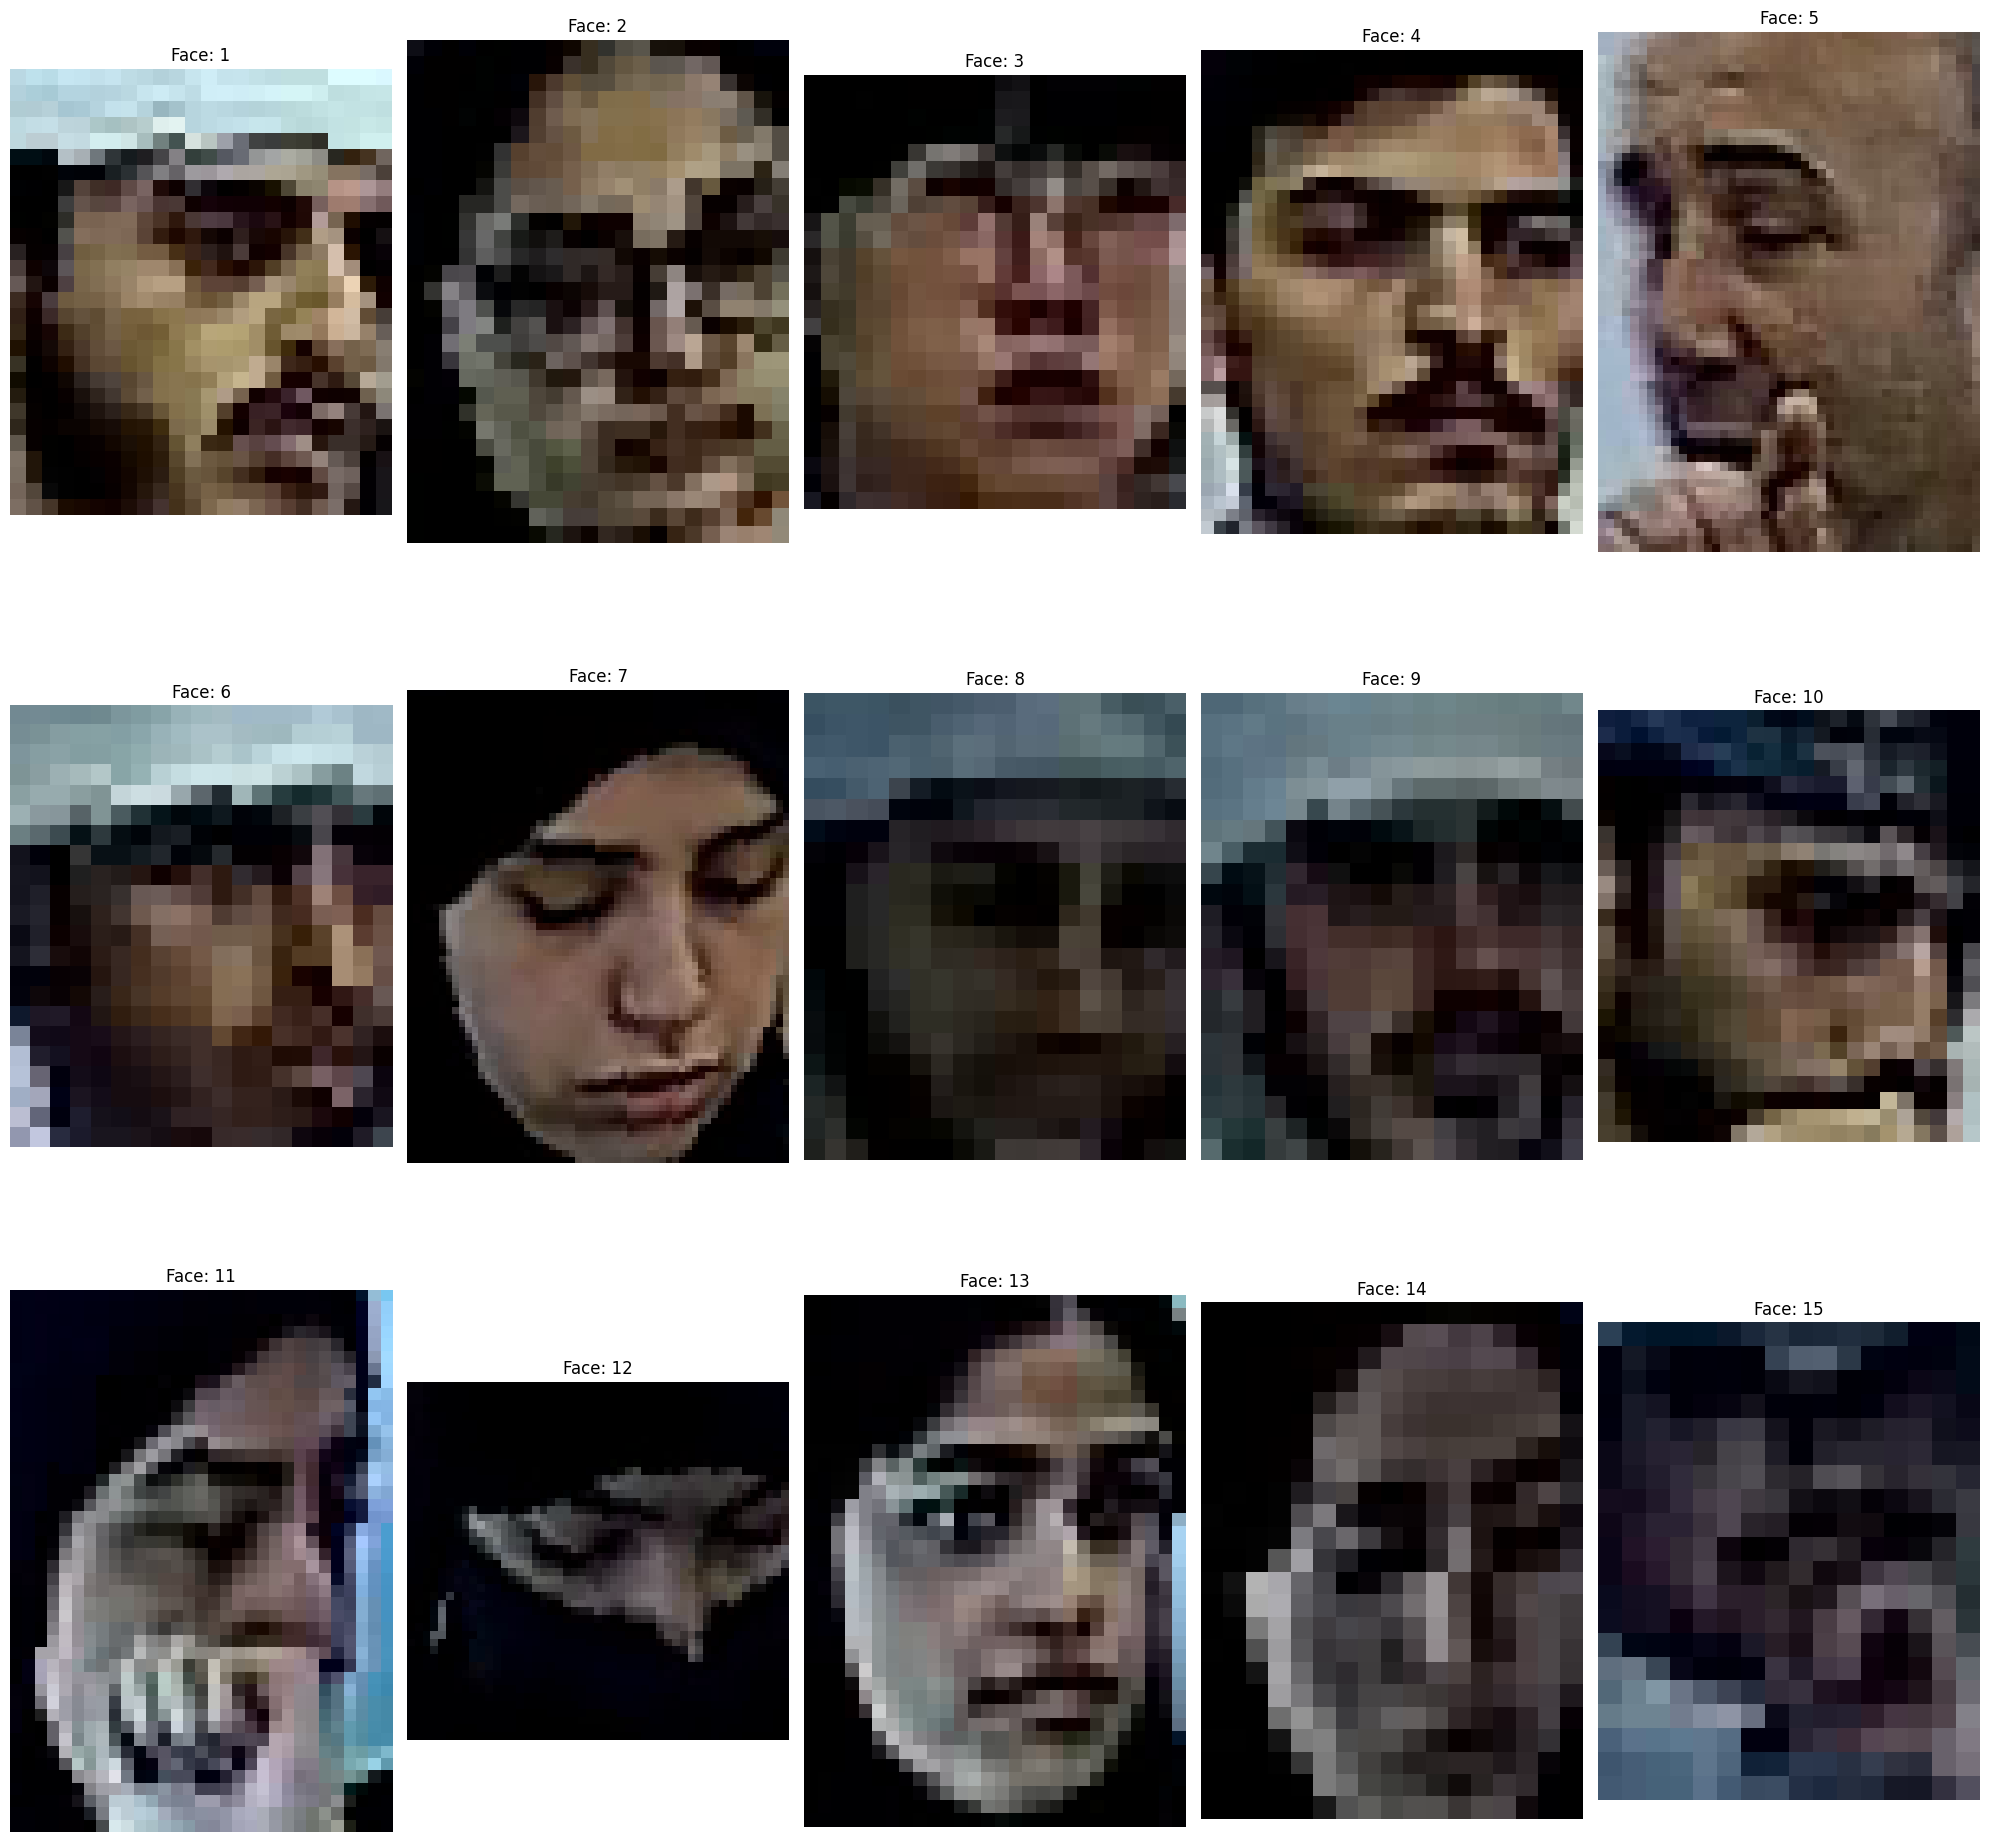

Signatures: (128,) 0
Signatures: (128,) 0.92
Signatures: (128,) 0
Signatures: (128,) 0.94
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0.93
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0.95
Signatures: (128,) 0
Signatures: (128,) 0


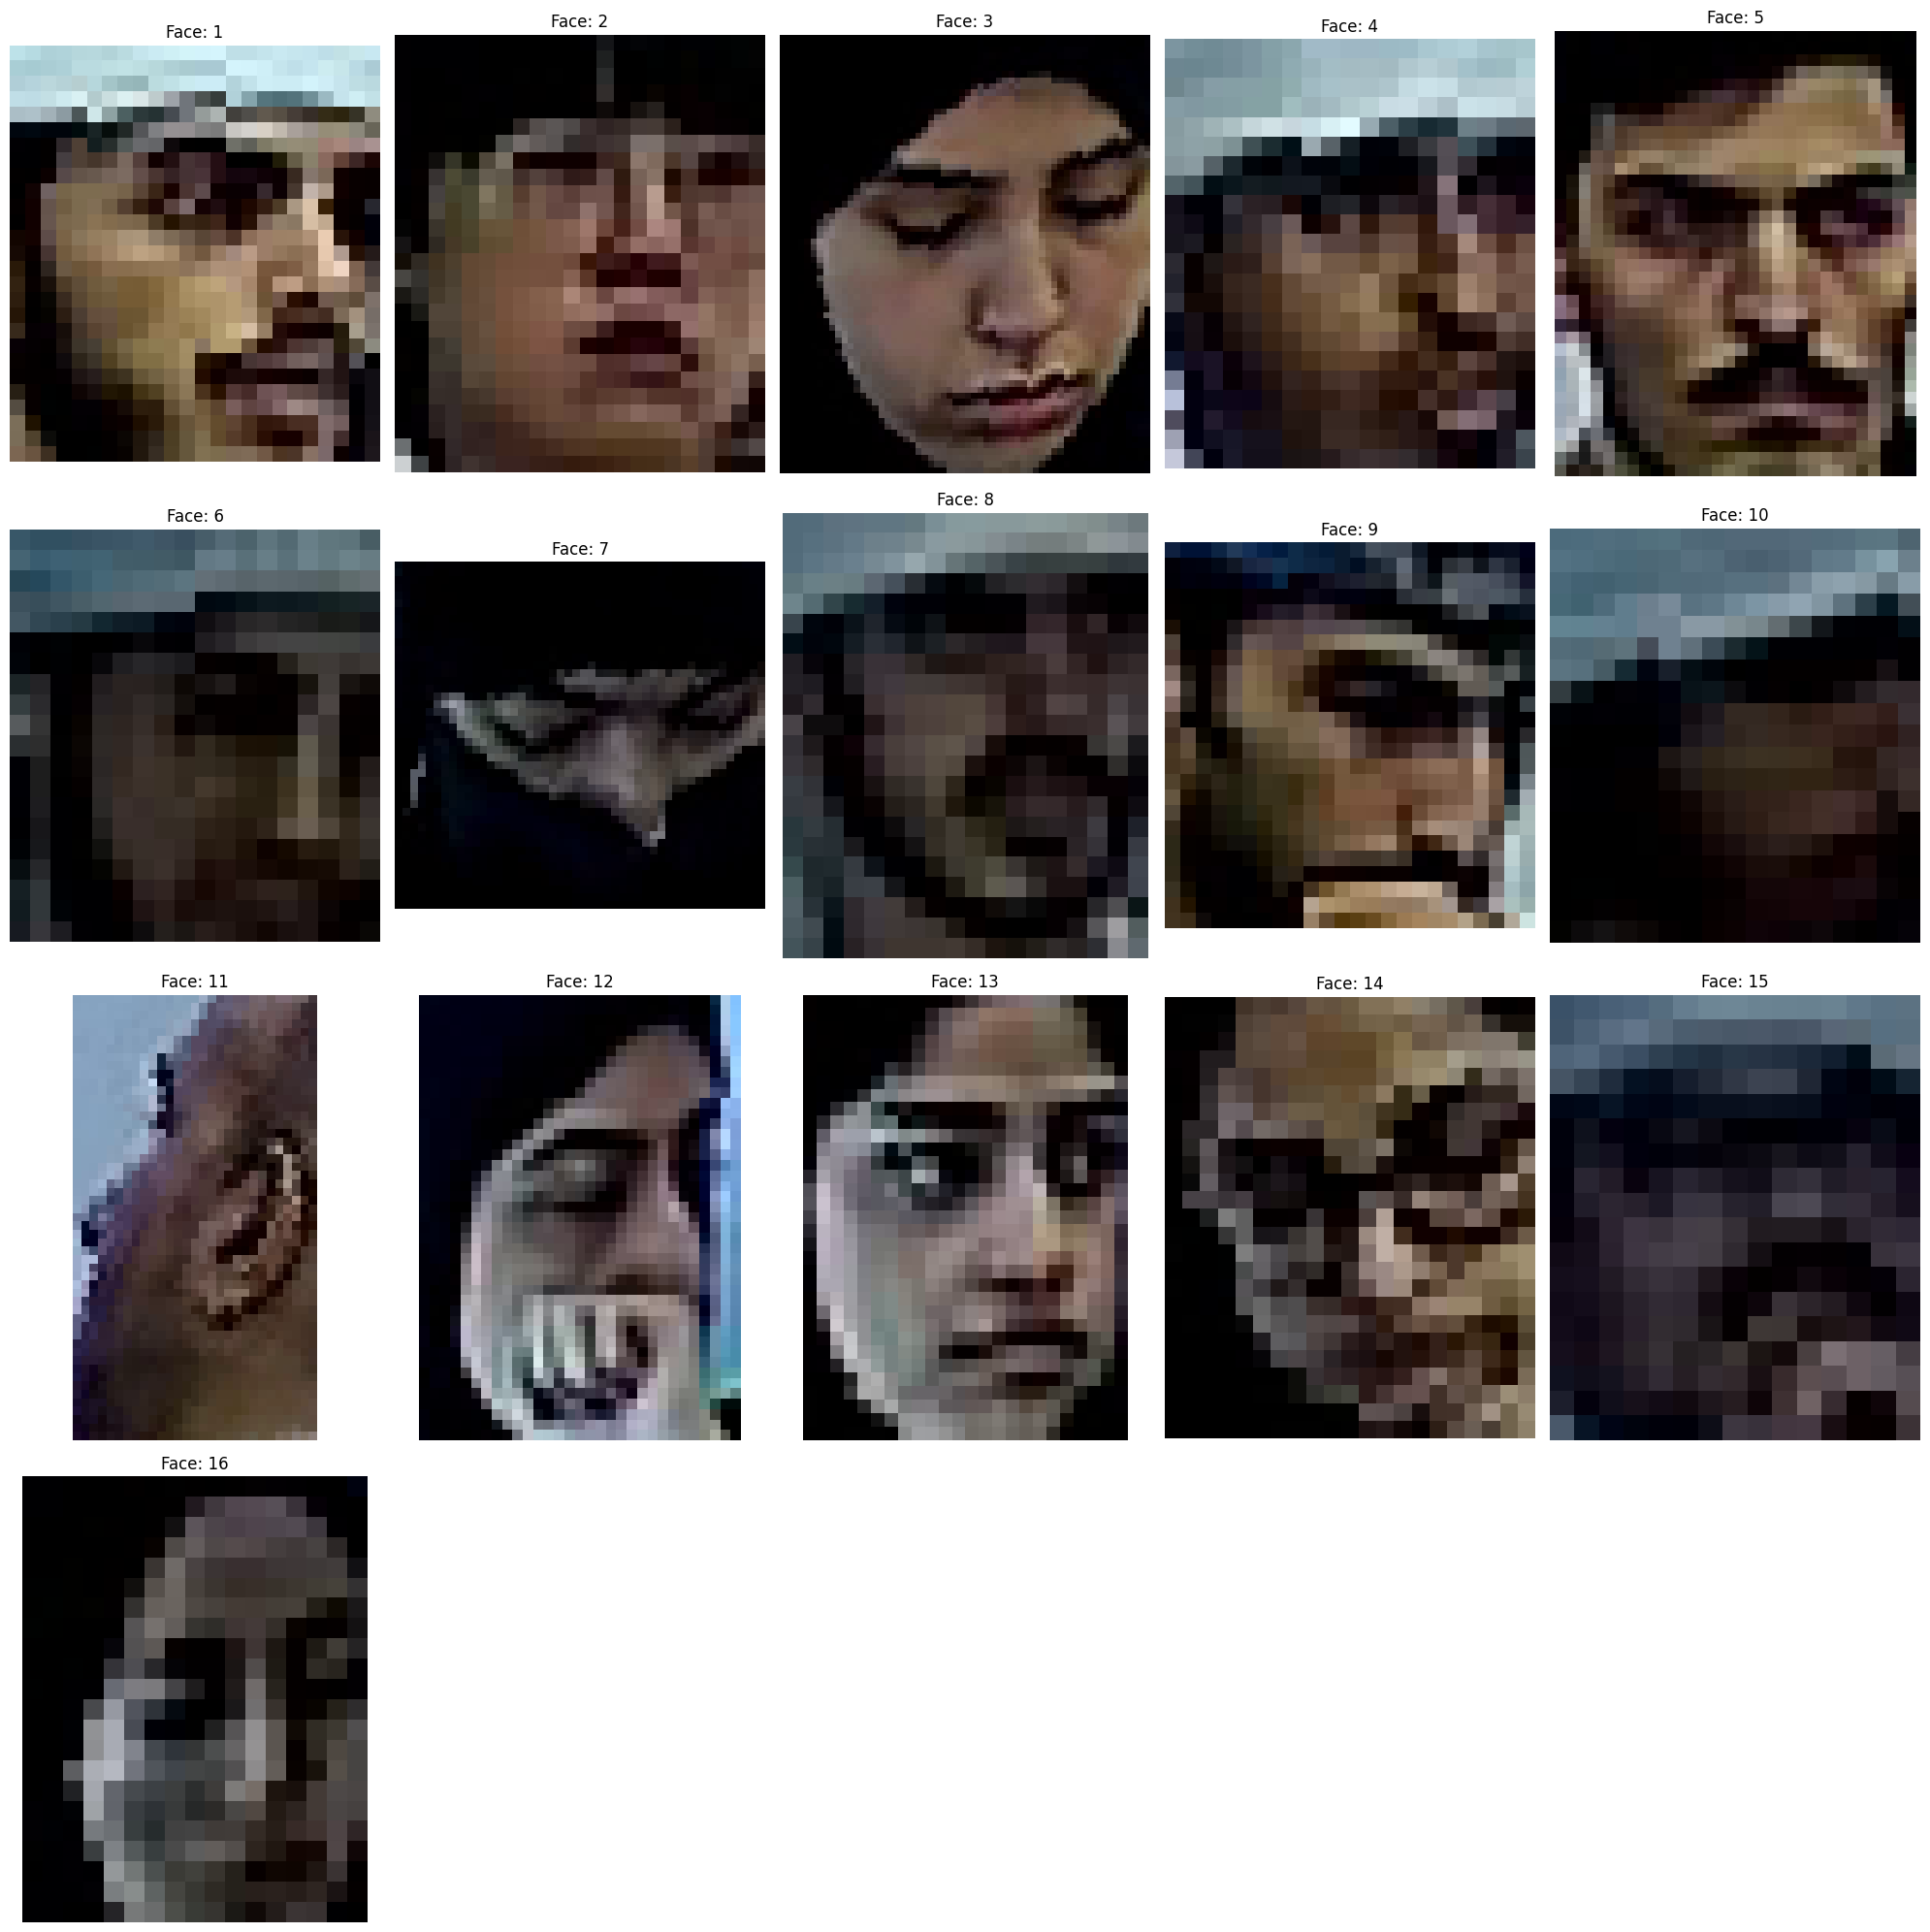

Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0.91
Signatures: (128,) 0
Signatures: (128,) 0.93
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0.95
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0


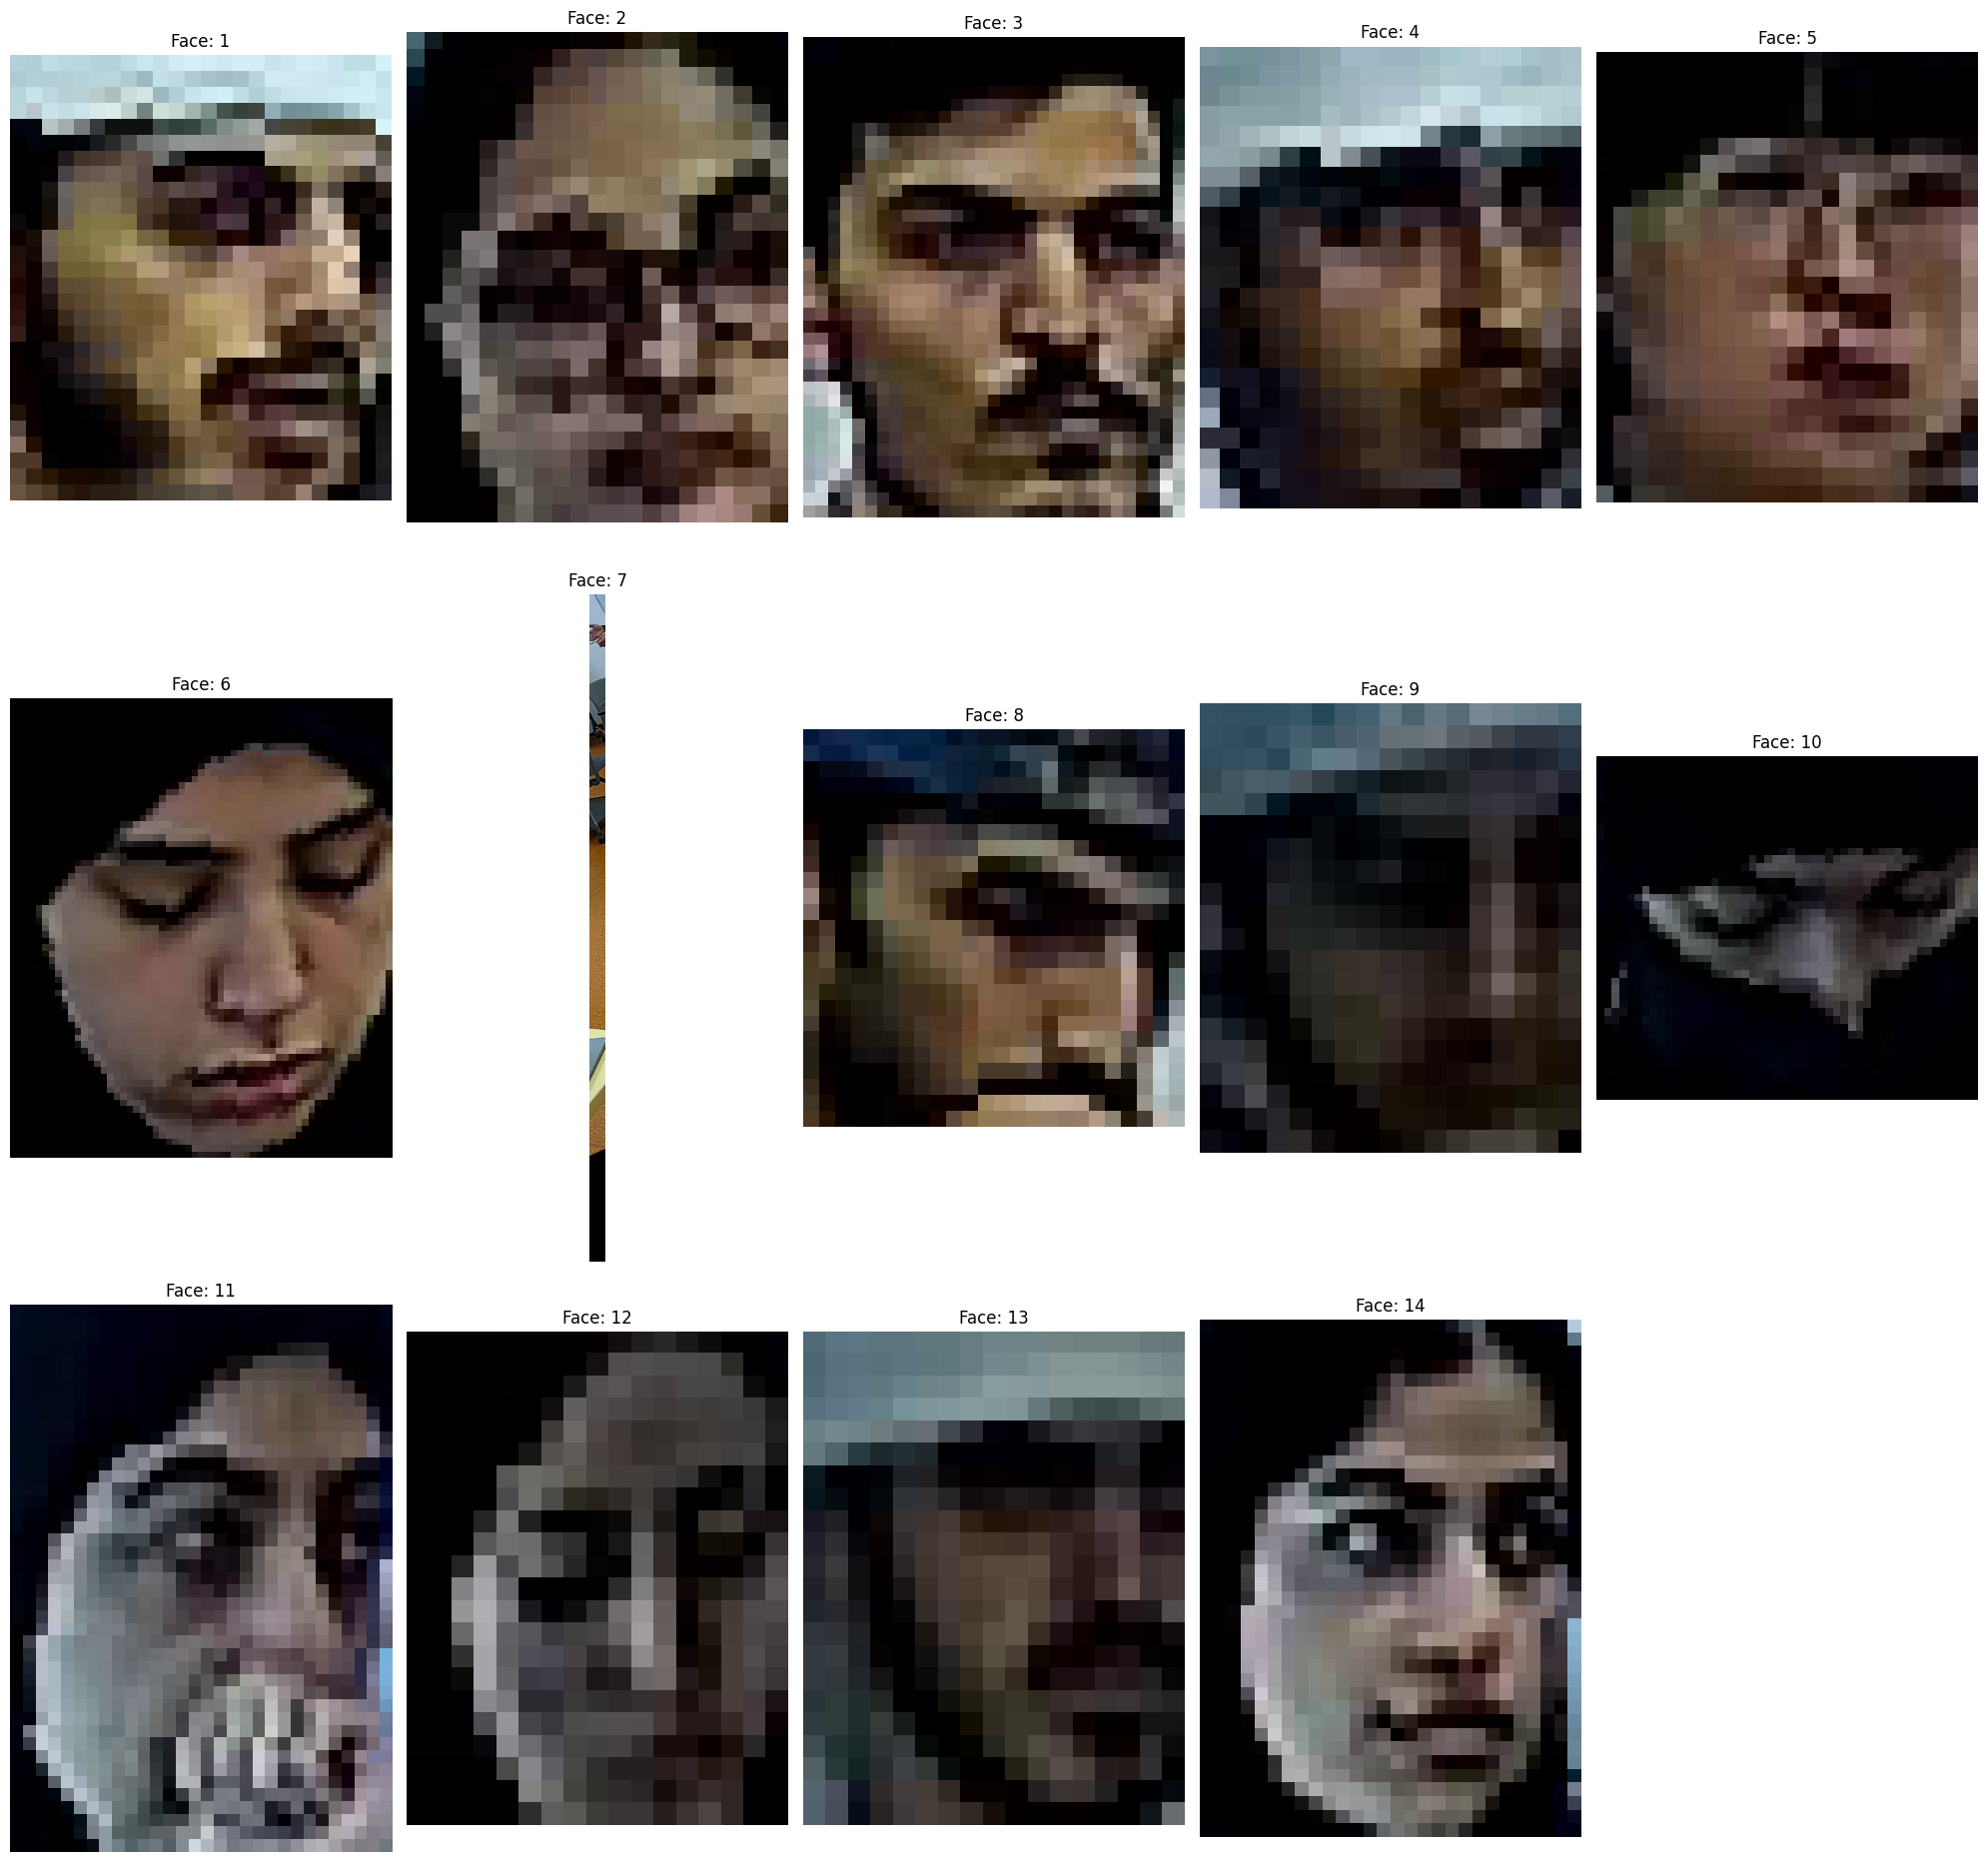

Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0.94
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0.92
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0.94


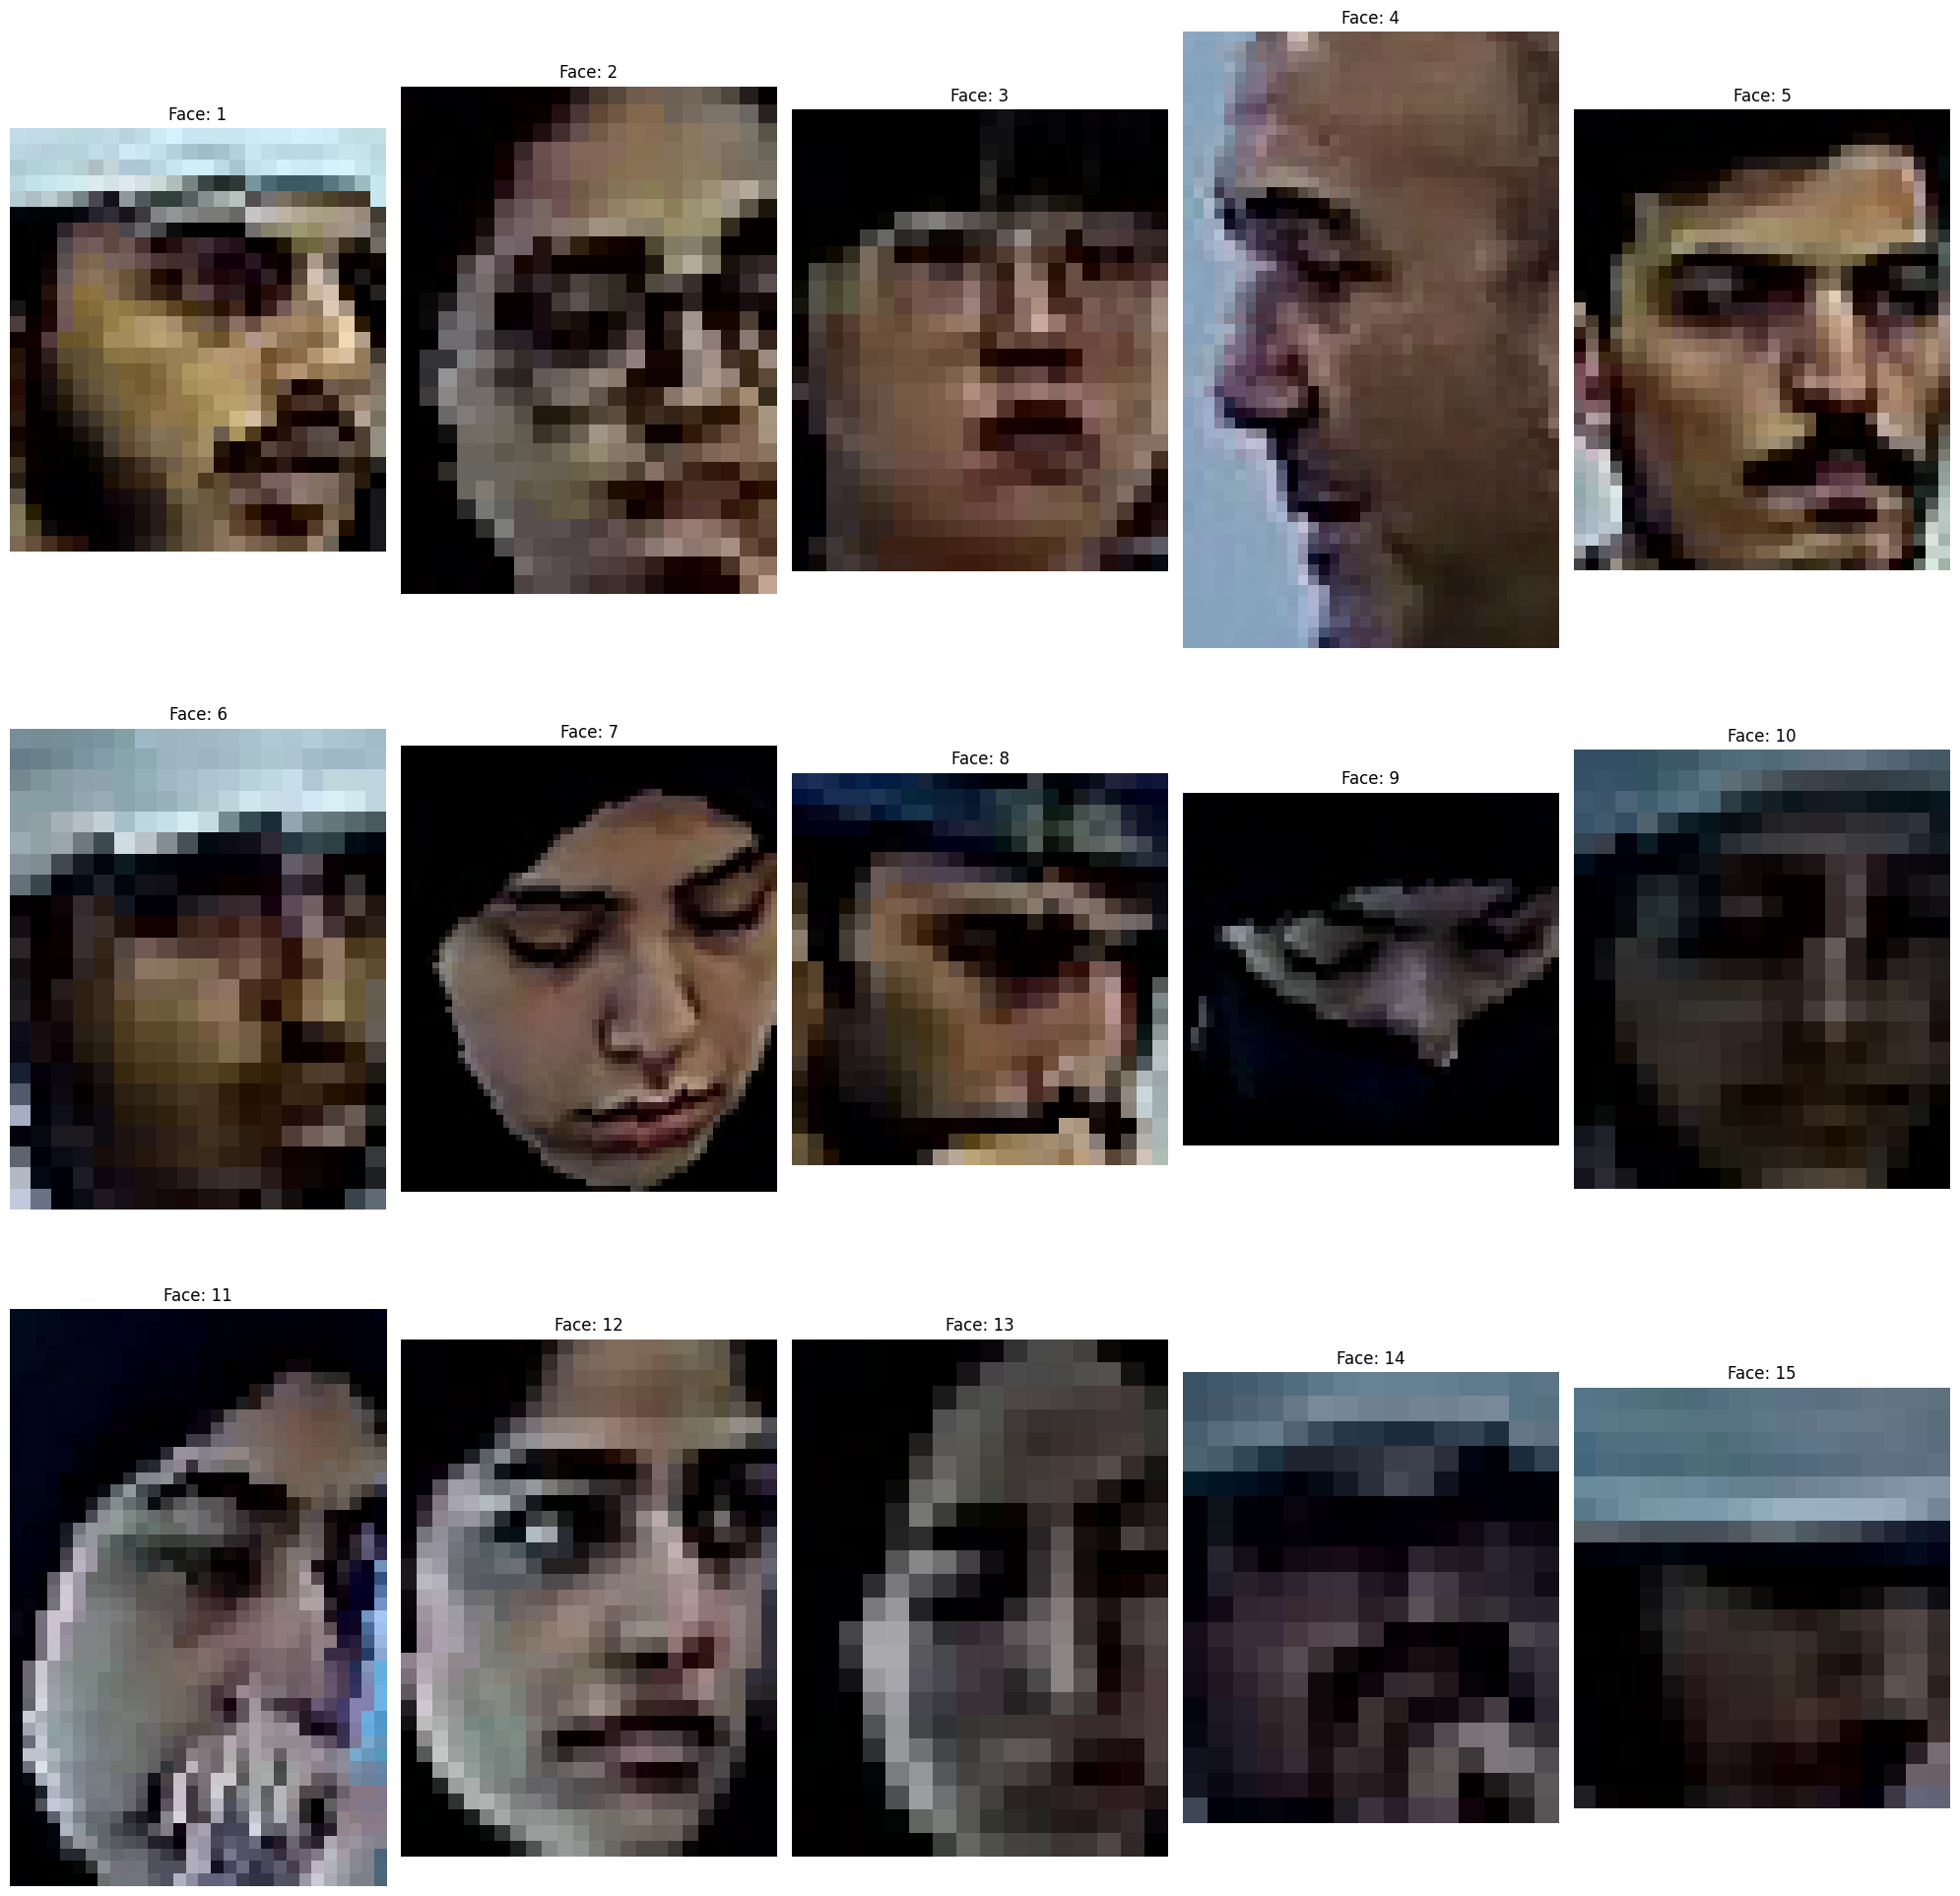

Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0.94
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0.92
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0


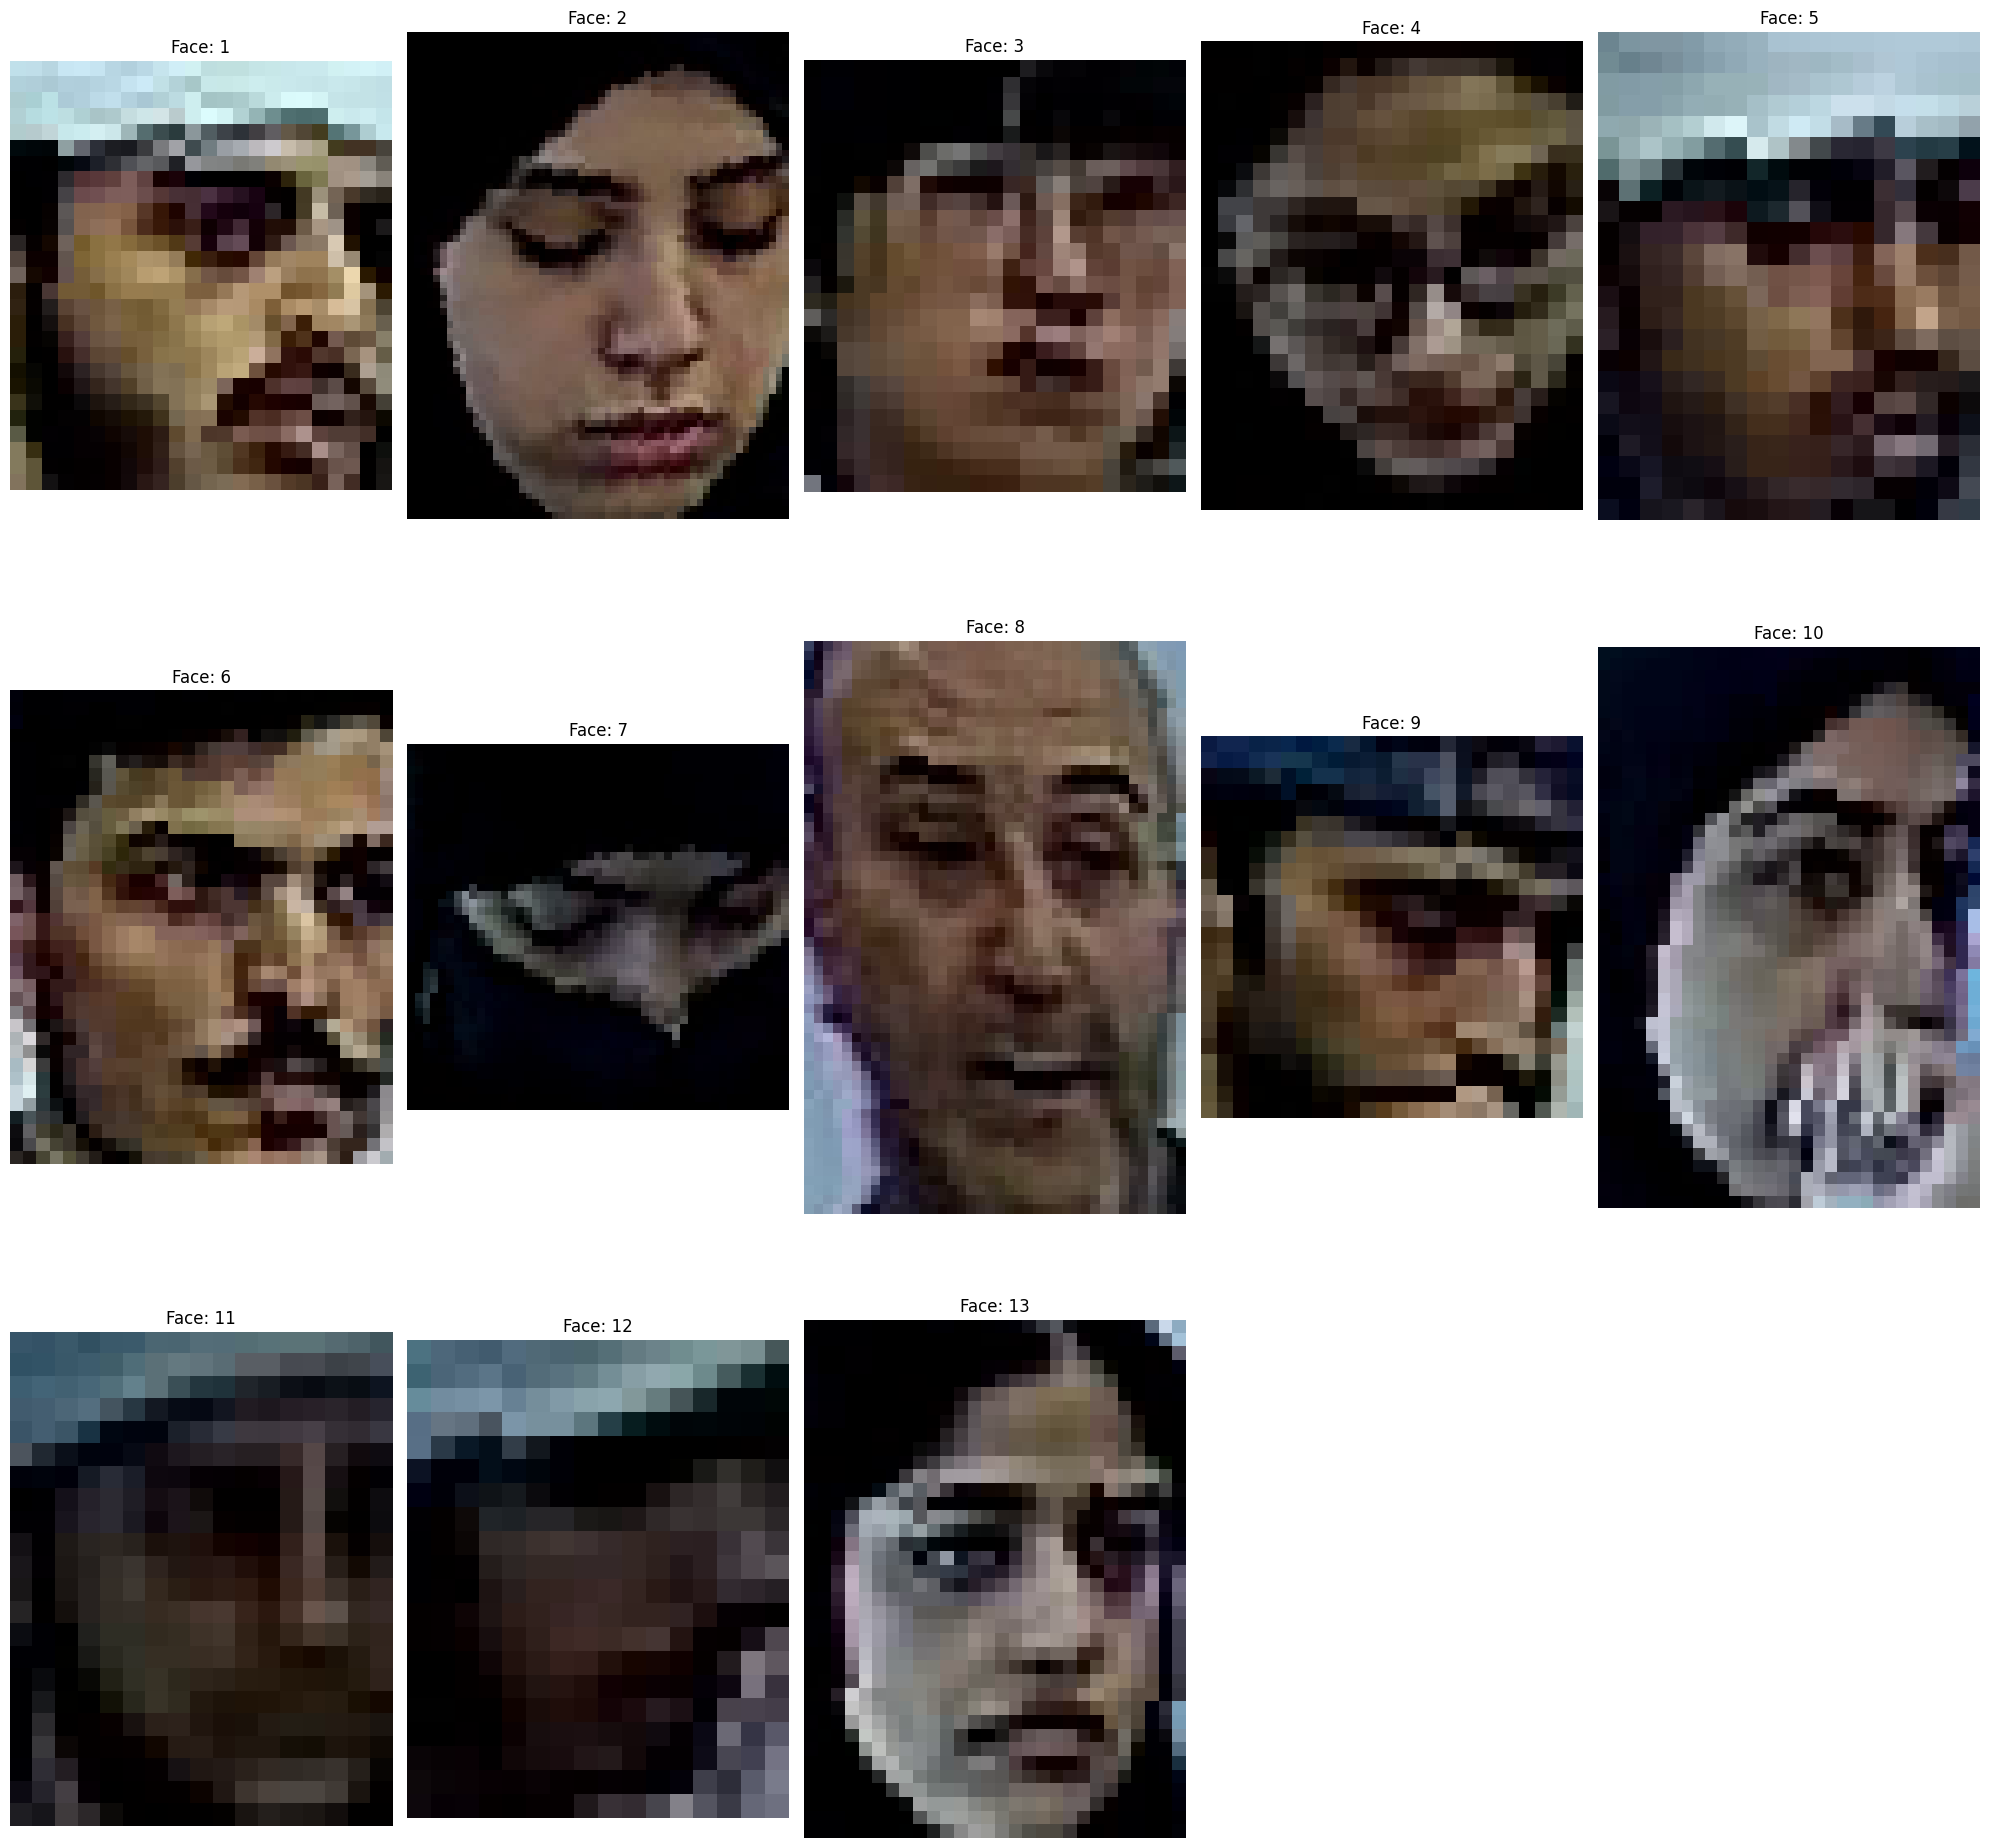

Signatures: (128,) 0
Signatures: (128,) 0.91
Signatures: (128,) 0
Signatures: (128,) 0.92
Signatures: (128,) 0
Signatures: (128,) 0.96
Signatures: (128,) 0
Signatures: (128,) 0.93
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0
Signatures: (128,) 0.97


KeyboardInterrupt: 

In [58]:
listOfFaces = []
for imgs in os.listdir("output"):
    listOfFaces.append(extract_imgs("output/"+imgs))

In [ ]:
# To save the data
import pickle

# Save to file
with open('C:/Users/Xxthe/Desktop/FaceRecognition/face_data.pkl', 'wb') as file:
    pickle.dump(listOfFaces, file)

In [46]:
listOfFaces

[[array([[[186, 216, 227],
          [190, 225, 236],
          [185, 220, 231],
          ...,
          [221, 252, 255],
          [221, 252, 255],
          [218, 248, 255]],
  
         [[179, 209, 220],
          [171, 206, 217],
          [167, 202, 213],
          ...,
          [192, 224, 225],
          [197, 229, 230],
          [198, 230, 231]],
  
         [[176, 204, 211],
          [177, 203, 211],
          [182, 208, 216],
          ...,
          [194, 226, 227],
          [194, 226, 227],
          [191, 223, 224]],
  
         ...,
  
         [[121, 109,  97],
          [ 33,  21,   9],
          [  2,   2,   2],
          ...,
          [110,  97,  92],
          [  2,   0,   3],
          [ 24,  21,  25]],
  
         [[116, 101,  90],
          [ 82,  70,  58],
          [  8,   8,   8],
          ...,
          [ 85,  72,  67],
          [  2,   0,   3],
          [ 24,  21,  25]],
  
         [[125, 110,  99],
          [ 97,  82,  71],
          [ 69,  53,  40

### Query Face Embedding with Detected Faces
1. Extract faces from the query image
2. Generate embeddings for the query image
3. Compare the Query Face Embedding with Detected Faces

In [ ]:
!python --version

In [ ]:
##
from numpy.linalg import norm

#query_img = cv2.imread("/content/drive/MyDrive/Research/Code/FaceRecognition/Images/S_001.jpg") # put you own patht

# Cosine similarity
def compute_similarity(embedding1, embedding2):
    return np.dot(embedding1, embedding2) / (norm(embedding1) * norm(embedding2))

compute_similarity(v1, v1)

In [ ]:
from numpy.linalg import norm
folder_name = "100060861"
file = "100060861_channel_1_face_85.png"
query_img = cv2.imread(os.path.join(folder_name, file)) # put you own path
print(os.path.join(folder_name, file))


# Cosine similarity
def compute_similarity(embedding1, embedding2):
    return np.dot(embedding1, embedding2) / (norm(embedding1) * norm(embedding2))

# Step 1: Extract query face and generate its embedding
query_faces = RetinaFace.extract_faces(query_img)
if len(query_faces) == 0:
    print(f"No faces detected in the query image.")

# Let's use the first detected face as the query face if detected
query_face = query_faces[0]

# Step 2: Generate embedding for the query face
query_signature = DeepFace.represent(
    query_face,
    model_name='ArcFace',
    enforce_detection=False
)

query_embedding = np.array(query_signature[0]['embedding']) # a 512-dimensional embedding
print(f"query_embedding: {query_embedding.shape}")
print(f"query score: {query_signature[0]['face_confidence']}")

# Step 3: Compare query face embedding with all detected faces
similarities = []
for faces in listOfFaces:
    for i, face in enumerate(faces):
        # Generate embedding for each detected face
        face_signature = DeepFace.represent(
            img_path=face,
            model_name="ArcFace",
            enforce_detection=False,
        )
        face_embedding = np.array(face_signature[0]["embedding"])

        # Compute similarity
        similarity = compute_similarity(query_embedding, face_embedding)
        similarities.append((i + 1, similarity))

        print(f"Face {i + 1}: Similarity with query face: {similarity:.4f}")

    # Step 4: Sort faces by similarity
    similarities = sorted(similarities, key=lambda x: x[1], reverse=True)  # Higher is more similar for cosine

    print("Similarity scores:", similarities)


100060861\100060861_channel_1_face_77.png
query_embedding: (512,)
query score: 0.95
Face 1: Similarity with query face: 0.0614
Face 2: Similarity with query face: -0.0174
Face 3: Similarity with query face: -0.0573
Face 4: Similarity with query face: -0.0007
Face 5: Similarity with query face: -0.1384
Face 6: Similarity with query face: -0.0097
Face 7: Similarity with query face: 0.2208
Face 8: Similarity with query face: 0.0030
Face 9: Similarity with query face: -0.0022
Face 10: Similarity with query face: -0.0108
Face 11: Similarity with query face: 0.0257
Face 12: Similarity with query face: -0.0293
Face 13: Similarity with query face: 0.1903
Face 14: Similarity with query face: -0.0117
Face 15: Similarity with query face: -0.0376
Similarity scores: [(7, np.float64(0.220837466136205)), (13, np.float64(0.19030264165656383)), (1, np.float64(0.06140143151873207)), (11, np.float64(0.02574935647482904)), (8, np.float64(0.0030170240802939786)), (4, np.float64(-0.000674648735306455)), (9,